In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\jiyam\netflix_cleaned.csv")

print(df.head())

    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                   Unknown   
2                   Unknown   
3                   Unknown   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole...   
1                                   Jandino Asporaat   
2  Peter Cullen, Sumalee Montano, Frank Welker, J...   
3  Will Friedle, Darren Criss, Constance Zimmer, ...   
4  Nesta Cooper, Kate Walsh, John Michael Higgins...   

                                    country date_added  release_year  \
0  United Sta

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv(r"C:\Users\jiyam\netflix_cleaned.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",9/9/2019,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,9/9/2016,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,9/8/2018,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,9/8/2018,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,9/8/2017,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017


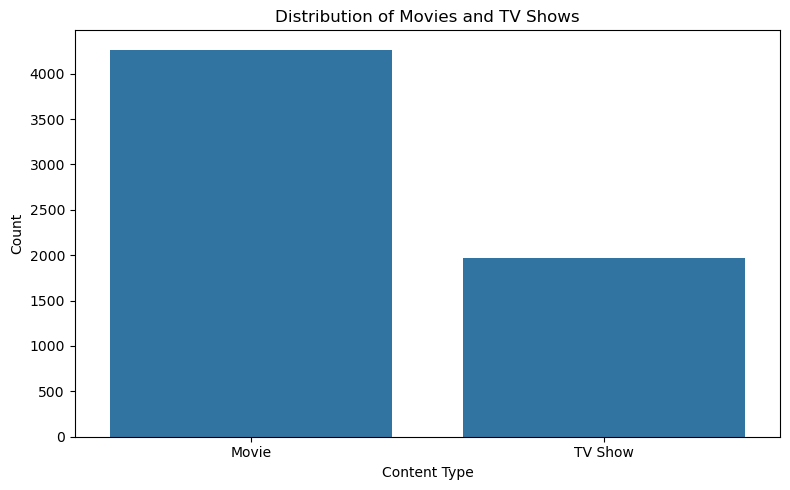

In [10]:
# Graph 1: Distribution of Movies and TV Shows

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='type')

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("type_distribution.png")

plt.show()

# Insight:
# Movies dominate Netflix's content library and significantly outnumber TV Shows.
# This indicates that Netflix focuses heavily on movie content while maintaining
# a smaller collection of TV series.

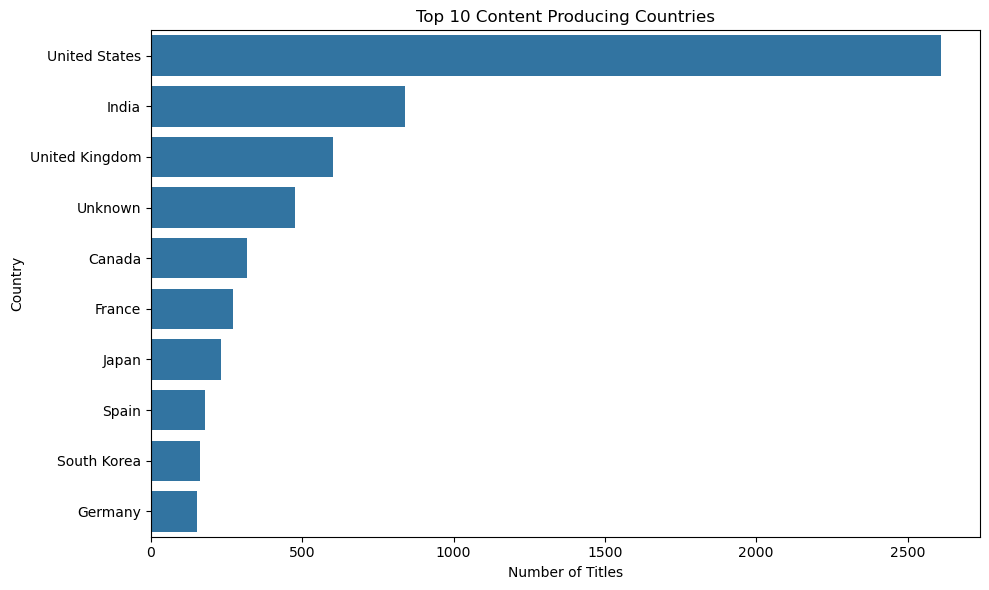

In [8]:
# Graph 2: Top 10 Content Producing Countries

countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
)

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("top_countries.png")

plt.show()

# Insight:
# The United States contributes the highest number of titles on Netflix,
# followed by countries such as India and the United Kingdom.
# This highlights Netflix's strong presence in major entertainment markets.

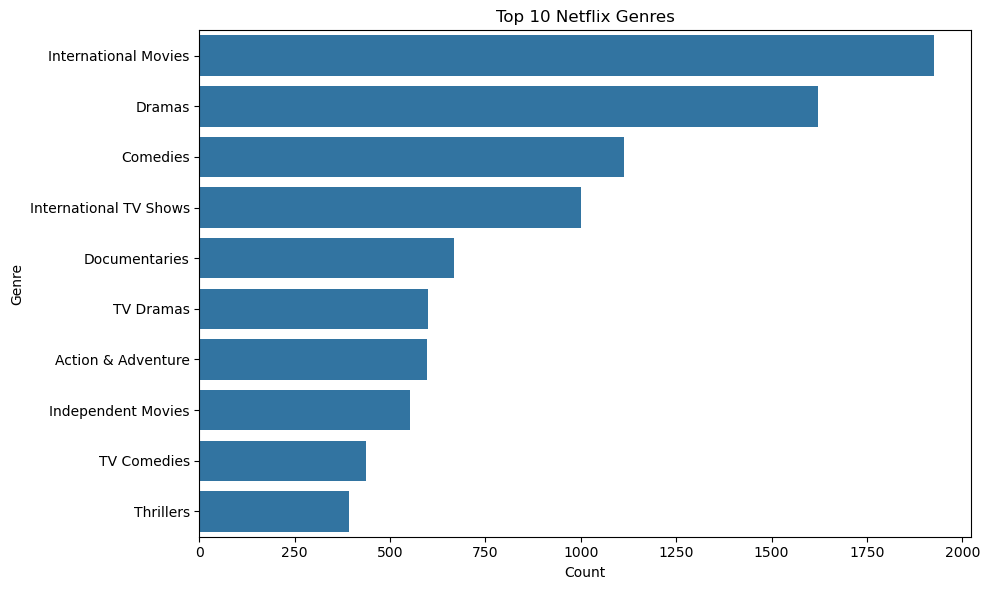

In [11]:
# Graph 3: Top 10 Netflix Genres

genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.tight_layout()
plt.savefig("genre_distribution.png")

plt.show()

# Insight:
# Dramas, International Movies, and Comedies are among the most popular genres
# on Netflix, reflecting diverse viewer preferences and content variety.

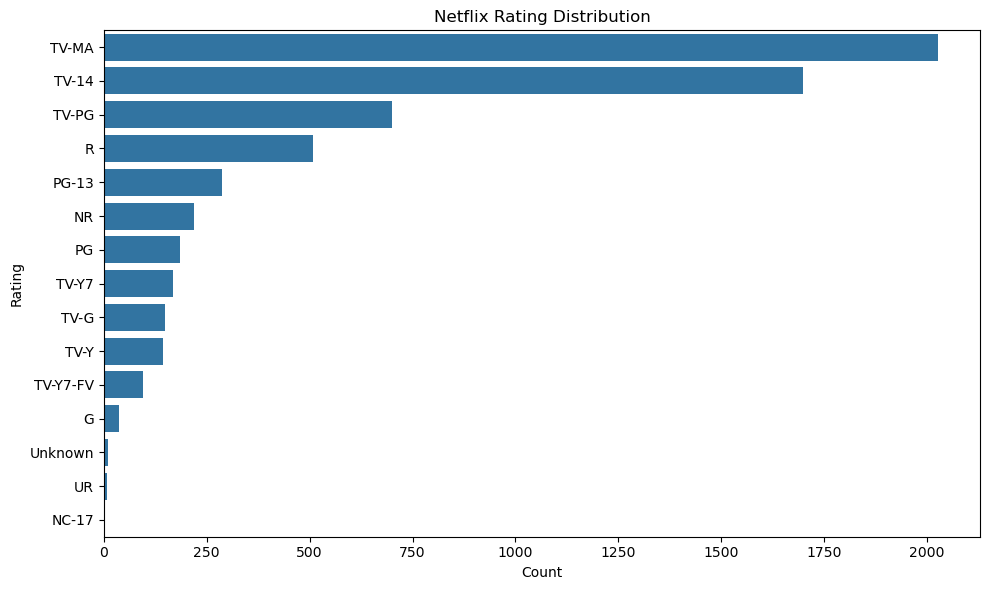

In [12]:
# Graph 4: Netflix Rating Distribution

plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Netflix Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.tight_layout()
plt.savefig("rating_distribution.png")

plt.show()

# Insight:
# TV-MA is the most common rating on Netflix, indicating that a significant
# portion of content is targeted toward mature audiences.

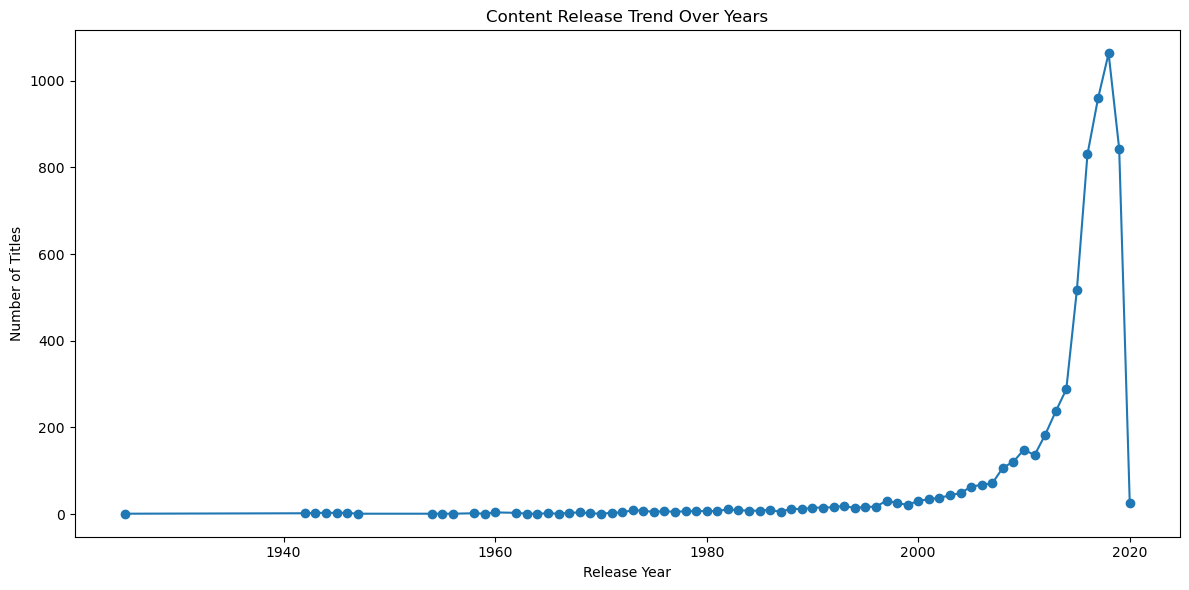

In [13]:
# Graph 5: Content Release Trend Over Years

release_year = (
    df['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    release_year.index,
    release_year.values,
    marker='o'
)

plt.title("Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.savefig("release_year_trend.png")

plt.show()

# Insight:
# The number of titles released has increased considerably over time,
# demonstrating growth in content production and Netflix's expanding catalog.

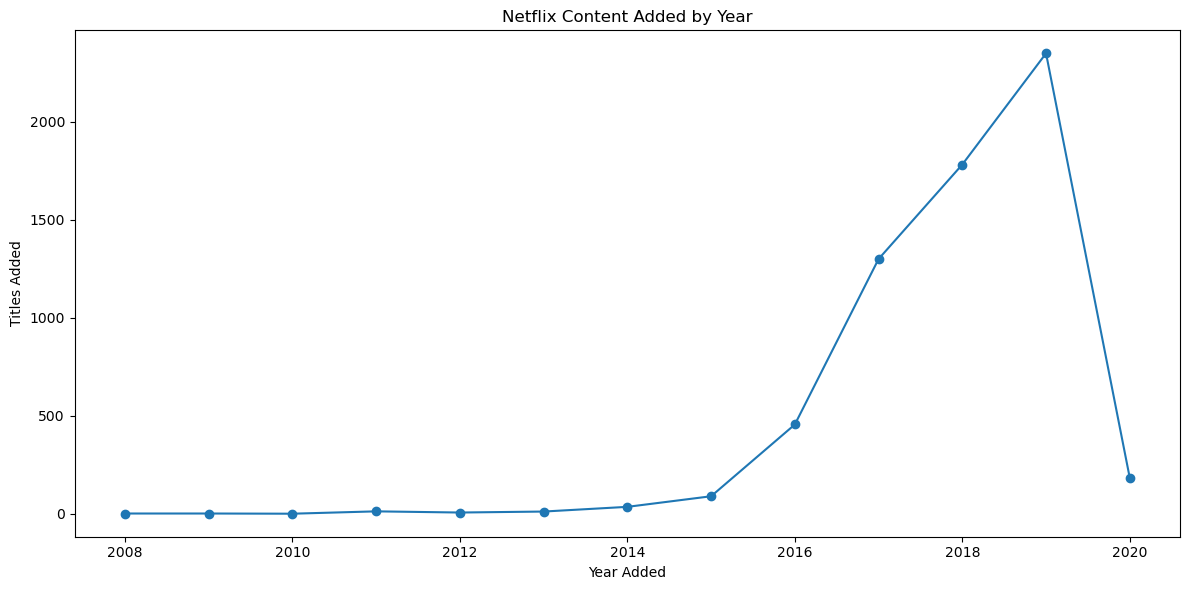

In [14]:
# Graph 6: Netflix Content Growth by Year Added

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

growth = (
    df['year_added']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    growth.index,
    growth.values,
    marker='o'
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Titles Added")

plt.tight_layout()
plt.savefig("content_growth_year.png")

plt.show()

# Insight:
# Netflix experienced rapid growth after 2015, with a significant increase
# in content additions, reflecting the platform's global expansion.

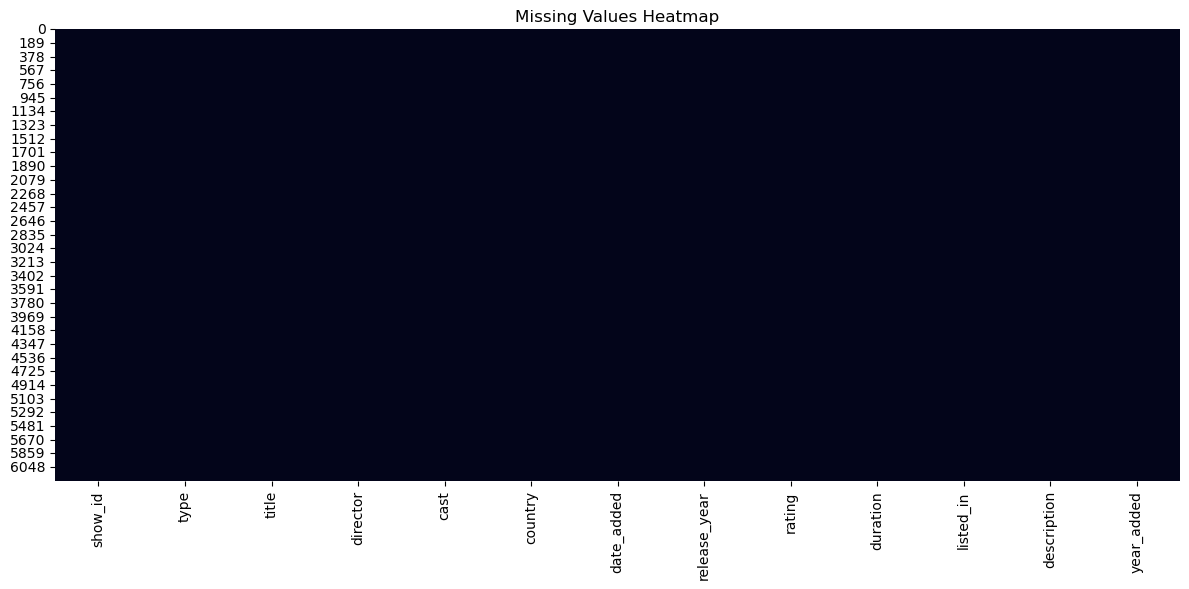

In [15]:
# Graph 7: Missing Values Heatmap

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.tight_layout()
plt.savefig("missing_values_heatmap.png")

plt.show()

# Insight:
# Several columns contain missing values, particularly director, cast,
# and country. These data quality issues should be addressed before
# advanced analysis.

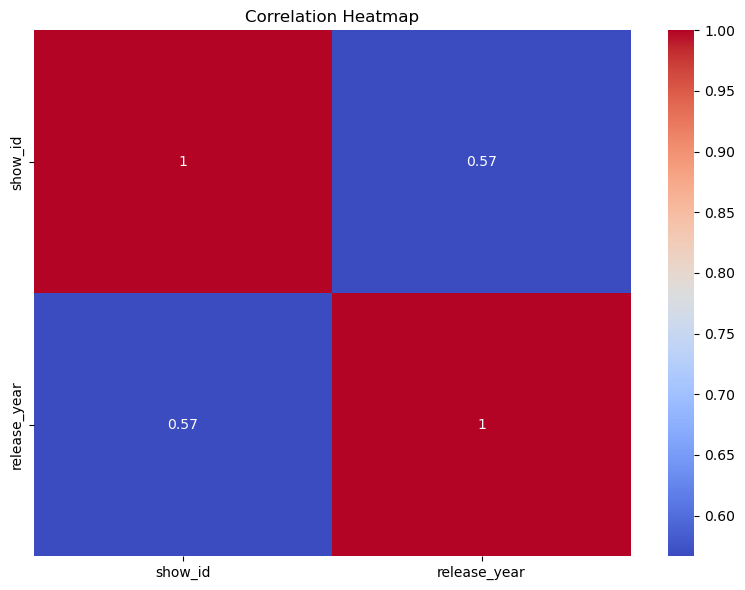

In [16]:
# Graph 8: Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("correlation_heatmap.png")

plt.show()

# Insight:
# The correlation heatmap displays relationships among numerical variables.
# Since the Netflix dataset contains limited numerical features, correlations
# are minimal but useful for exploratory analysis.